In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')

In [3]:
df.drop(['day','month','year'],axis=1,inplace=True)

In [4]:
#Encoding
df['Classes'] = np.where(df['Classes'].str.contains('not fire'),0,1)

In [5]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [6]:
X = df.drop('FWI',axis=1)
y = df['FWI']

In [7]:
#Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

### Feature Selection

In [8]:
def correlation(dataset,threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [9]:
## Threshold--Domain expertise
corr_features = correlation(X_train,0.85)

In [10]:
## Drop features when correlation is more than 0.85
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)


## Feature Scaling or Standardization

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Box Plots To Understand Effect of Standard Scaler


Text(0.5, 1.0, 'X_train After Scaling')

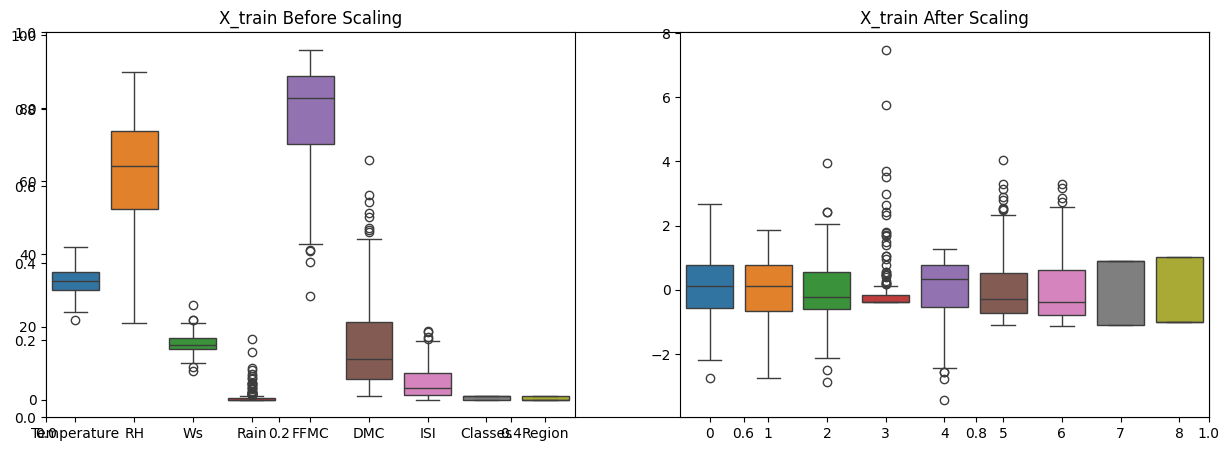

In [12]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title('X_train Before Scaling')
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After Scaling')

## Linear Regression 

MAE :  0.5468236465249978
R2 Score :  0.9847657384266951


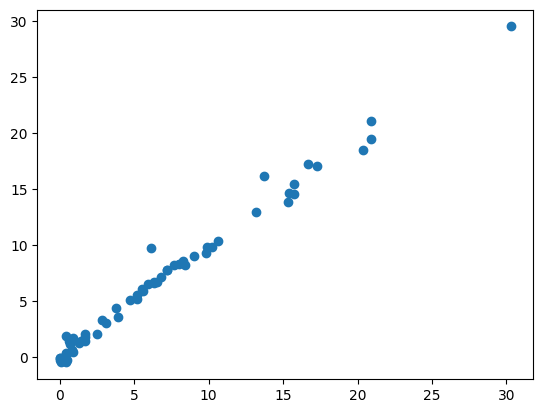

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg = LinearRegression()
linreg.fit(X_train_scaled,y_train)
y_pred = linreg.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("MAE : ",mae)
print("R2 Score : ",score)
plt.scatter(y_test,y_pred)

## Lasso Regression

MAE :  1.133175994914409
R2 Score :  0.9492020263112388


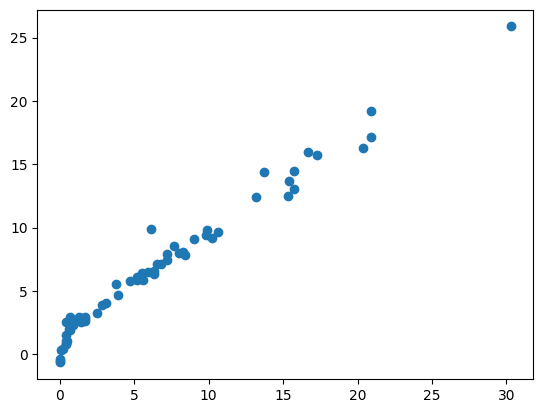

In [14]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasreg = Lasso()
lasreg.fit(X_train_scaled,y_train)
y_pred = lasreg.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("MAE : ",mae)
print("R2 Score : ",score)
plt.scatter(y_test,y_pred)

## Ridge Regression

MAE :  0.5642305340105715
R2 Score :  0.9842993364555512


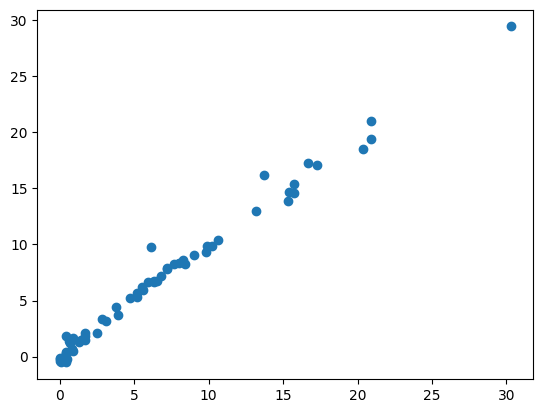

In [15]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridreg = Ridge()
ridreg.fit(X_train_scaled,y_train)
y_pred = ridreg.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("MAE : ",mae)
print("R2 Score : ",score)
plt.scatter(y_test,y_pred)

## ElasticNet Regression

MAE :  1.8822353634896005
R2 Score :  0.8753460589519703


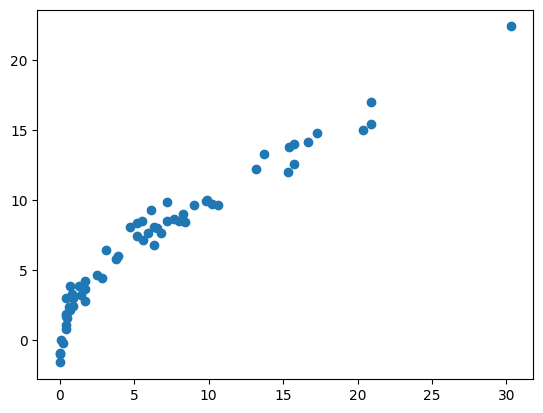

In [16]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elasticnet = ElasticNet()
elasticnet.fit(X_train_scaled,y_train)
y_pred = elasticnet.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("MAE : ",mae)
print("R2 Score : ",score)
plt.scatter(y_test,y_pred)

# Cross Validation Lasso

MAE :  0.619970115826343
R2 Score :  0.9820946715928275


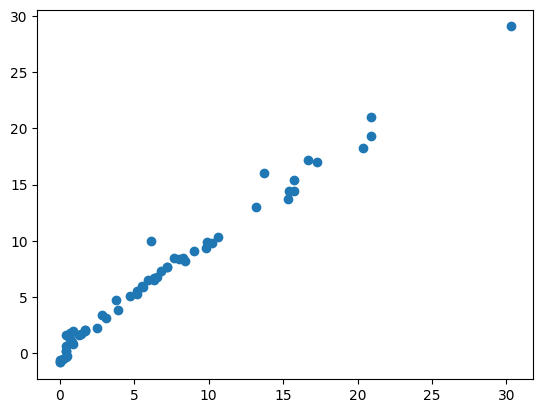

In [17]:

from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv=5)
lassocv.fit(X_train_scaled,y_train)
lassocv.alphas_
y_pred = lassocv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("MAE : ",mae)
print("R2 Score : ",score)

### RidgeCV Regression

MAE :  0.5642305340105715
R2 Score :  0.9842993364555512


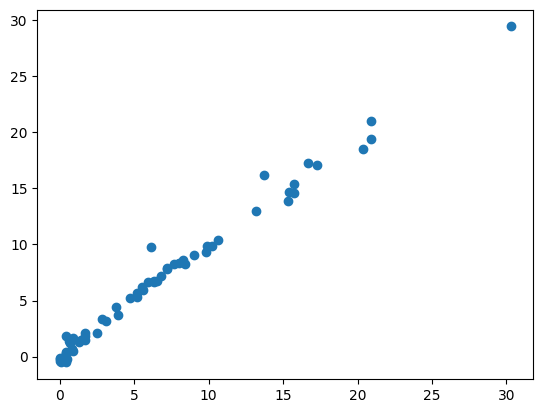

In [18]:
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
y_pred = ridgecv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("MAE : ",mae)
print("R2 Score : ",score)

## ElasticNetCV Regression

MAE :  0.6575946731430898
R2 Score :  0.9814217587854941


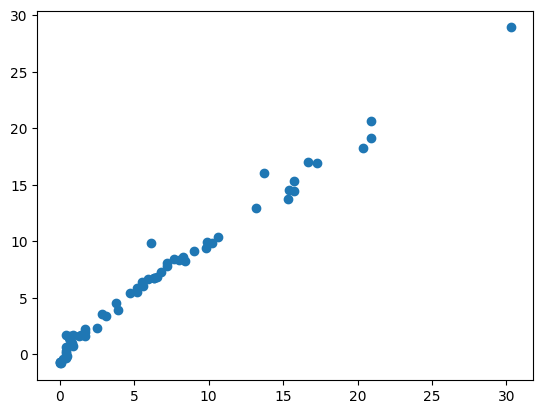

In [19]:
from sklearn.linear_model import ElasticNetCV
elascv = ElasticNetCV(cv=5)
elascv.fit(X_train_scaled,y_train)
y_pred = elascv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("MAE : ",mae)
print("R2 Score : ",score)

## Pickle the Machine Learning models, preprocessing model StandardScaler

In [20]:
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(ridreg,open('ridge.pkl','wb'))